# Drug Separation

These are clearly separating much more strongly by cell line than perturbation. here, we will attempt to achieve an embedding that demonstrates good drug perturbation separation.

In [5]:
import os
import ast
import json
import joblib
from joblib import Parallel, delayed
import time

from tqdm import tqdm
from tqdm import trange

import numpy as np
import pandas as pd

from scipy import stats
from sklearn.metrics import normalized_mutual_info_score
from sklearn.linear_model import LinearRegression 

from sklearn.preprocessing import OneHotEncoder

from kneed import KneeLocator

import scanpy as sc
import umap

import matplotlib.pyplot as plt
import seaborn as sns

import Tahoe_utils as Tu

import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io

In [6]:
n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
author = 'Tahoe100M'

In [7]:
tf_adata = io.read_tfad(os.path.join(data_path, 'processed', author + '_consensus_tf_activity.h5ad'))

Step 1: Fit a PLS-DA model of drug ~ TF activity , including confounders (cell line, plate, cell cycle scores) as X covariates to remove those sources of variance.
- since only cell line information will be available in the generative model, we only control for this (we need to be able to project the predicted data into this space)
#- categorical confounders (cell line and plate) are one-hot encoded
#- continuous confounders (cell cycle scores) are scaled
- X (TF activity) is not scaled because it is the consensus Z-score from decoupler

We will identify an optimal n components by assessing the following:
1) Mean accuracy score across 5-fold CV of a logistic regression classifier trained on the PLS components (cannot directly use PLS model CV because it is technically a regression model on the one-hot encodings, and the high R^2 does not necessarily mean high classification accuracy)
2) Explained variance in the X and y blocks

In [9]:
# assessment_df = []
# pls_components_max = 25
# for n_components in tqdm(range(pls_components_max, 0, -1)): #(1, pls_components_max + 1):
#     _, assessment, _= Tu.pls_da(adata = tf_adata, 
#                                  n_components = n_components ,
#                                  control_confounders = True, 
#                                  assess = True,
#                              return_components = True, 
#                                  seed = seed, 
#                             enc_X = None, 
#                             enc_Y = None)
#     assessment_df.append(assessment)
    
# assessment_df = pd.DataFrame(assessment_df)
# assessment_df = assessment_df.sort_values(by = 'n_components').reset_index(drop = True)
# assessment_df.to_csv(os.path.join(data_path, 'interim', author + '_PLS_drug_scores.csv'))

assessment_df = pd.read_csv(os.path.join(data_path, 'interim', author + '_PLS_drug_scores.csv'), 
                            index_col =0)

''

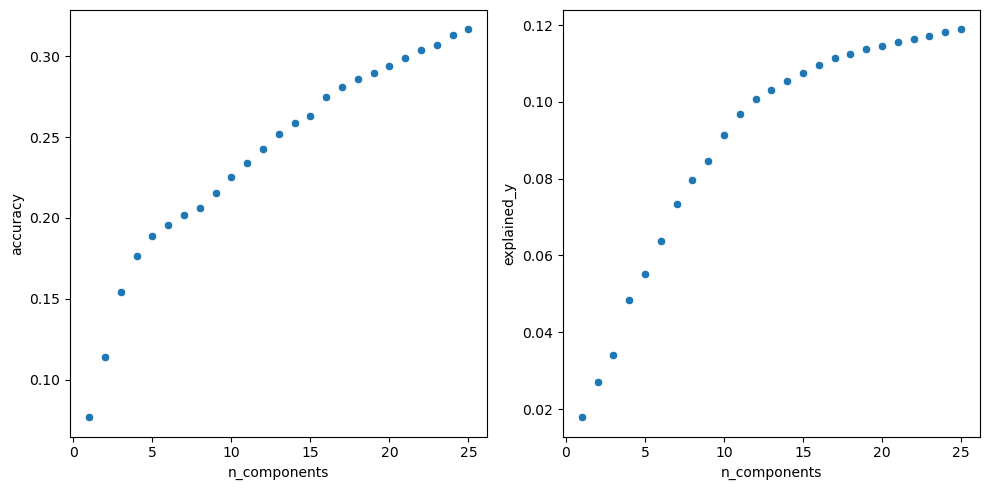

In [10]:
fig, ax = plt.subplots(ncols = 2, figsize=(10,5))

for (j, metric) in enumerate(['accuracy', 'explained_y']):
    sns.scatterplot(data = assessment_df, x = 'n_components', y = metric, ax = ax[j])
    
fig.tight_layout()
;


In [11]:
y_ax = assessment_df.accuracy
x_ax = np.array(range(len(y_ax))) + 1
kneedle = KneeLocator(x = x_ax, y = y_ax, curve='concave', direction='increasing')
n_component_elbow = kneedle.elbow
n_component_elbow

5

In [12]:
y_ax = assessment_df.explained_y
x_ax = np.array(range(len(y_ax))) + 1
kneedle = KneeLocator(x = x_ax, y = y_ax, curve='concave', direction='increasing')
n_component_elbow = kneedle.elbow
n_component_elbow

11

In [14]:
assessment_df

,n_components,accuracy,explained_y
0,1,0.076679,0.017850
1,2,0.113706,0.026980
2,3,0.154137,0.033983
3,4,0.176590,0.048354
4,5,0.189024,0.055269
5,6,0.195464,0.063774
6,7,0.201937,0.073407
7,8,0.206156,0.079562
8,9,0.215607,0.084719
9,10,0.225613,0.091438


In [15]:
component_differences = ['-'.join(['Component {}'.format(i), 'Component {}'.format(i-1)]) for i in range(1, assessment_df.shape[0] + 1)][1:]
component_differences.insert(0, np.nan)

delta = assessment_df.diff()
delta.n_components = component_differences

In [16]:
delta

,n_components,accuracy,explained_y
0,NaN,NaN,NaN
1,Component 2-Component 1,0.037027,0.009130
2,Component 3-Component 2,0.040431,0.007003
3,Component 4-Component 3,0.022452,0.014371
4,Component 5-Component 4,0.012434,0.006915
5,Component 6-Component 5,0.006440,0.008505
6,Component 7-Component 6,0.006473,0.009633
7,Component 8-Component 7,0.004219,0.006155
8,Component 9-Component 8,0.009451,0.005158
9,Component 10-Component 9,0.010006,0.006719


For now, we won't do permutation testing to assess the significance of the model since it takes a long time to fit. We will simply assess by the added CV accuracy and variance explained.

Let's see whether the PLS components can better explain the variance when compared to PCA:

In [17]:
%%time
n_best_components = 5
models, assessment, X_pls = Tu.pls_da(adata = tf_adata, 
                                      n_components = n_best_components,
                                      control_confounders = True, 
                                      assess = True,
                                      return_components = True,
                                      seed = seed, 
                         enc_X = None, 
                         enc_Y = None)
pls_model = models['pls_model']


CPU times: user 15min 17s, sys: 46.1 s, total: 16min 3s
Wall time: 3min 18s


In [18]:
assessment

{'n_components': 5,
 'accuracy': 0.18902433014078954,
 'explained_y': 0.055269235893476876}

In [19]:
proj_df = pd.DataFrame(X_pls)
proj_df.columns = ['PLS{}'.format(i+1) for i in range(proj_df.shape[1])]

In [20]:
res = []
for cov_ in ['drug', 'cell_line']:
    cov = tf_adata.obs[cov_].astype(str)
    enc = OneHotEncoder(drop="first", sparse_output=False)
    cov_encoded = enc.fit_transform(cov.values.reshape(-1, 1))

    r2_scores = []
    for pls_idx in trange(proj_df.shape[1]):
        y = proj_df.iloc[:, pls_idx]
        model = LinearRegression().fit(cov_encoded, y)
        r2 = model.score(cov_encoded, y)
        r2_scores.append({"PLS": pls_idx + 1, "R2": r2})

    r2_df = pd.DataFrame(r2_scores)
    r2_df['covariate'] = cov_
    res.append(r2_df)
    
r2_df = pd.concat(res, axis=0, ignore_index=True)


100%|█████████████████████████████████████| 5/5 [00:00<00:00,  5.69it/s]


In [21]:
r2_df.groupby('covariate').R2.mean()

covariate
cell_line    0.244678
drug         0.309508
Name: R2, dtype: float64

In [22]:
r2_df.groupby('covariate').R2.median()

covariate
cell_line    0.342175
drug         0.255649
Name: R2, dtype: float64

In [23]:
r2_df

,PLS,R2,covariate
0,1,0.499787,drug
1,2,0.255649,drug
2,3,0.196095,drug
3,4,0.402391,drug
4,5,0.193617,drug
5,1,0.035796,cell_line
6,2,0.342175,cell_line
7,3,0.368093,cell_line
8,4,0.133156,cell_line
9,5,0.344169,cell_line


Text(0.5, 0, 'Covariate')

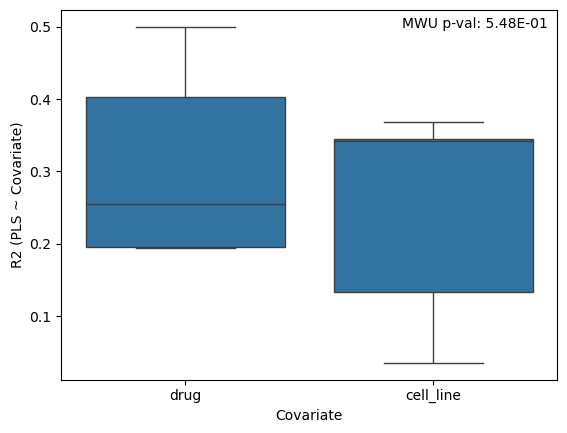

In [24]:
fig, ax = plt.subplots()

pval = stats.mannwhitneyu(r2_df[r2_df.covariate == 'drug'].R2, 
                  r2_df[r2_df.covariate == 'cell_line'].R2).pvalue
sns.boxplot(data = r2_df, x = 'covariate', y = 'R2', ax = ax)

ax.annotate(
    "MWU p-val: {:.2E}".format(pval),
    xy=(0.98, 0.98),
    xycoords="axes fraction",
    ha="right",
    va="top"
)

ax.set_ylabel('R2 (PLS ~ Covariate)')
ax.set_xlabel('Covariate')
# ax.set_title('Top 2 PLS')

In [25]:
proj_df['drug'] = tf_adata.obs.drug.values
proj_df['cell_line'] = tf_adata.obs.cell_line.values
proj_df['condition'] = proj_df.drug.astype(str) + '^' + proj_df.cell_line.astype(str)

''

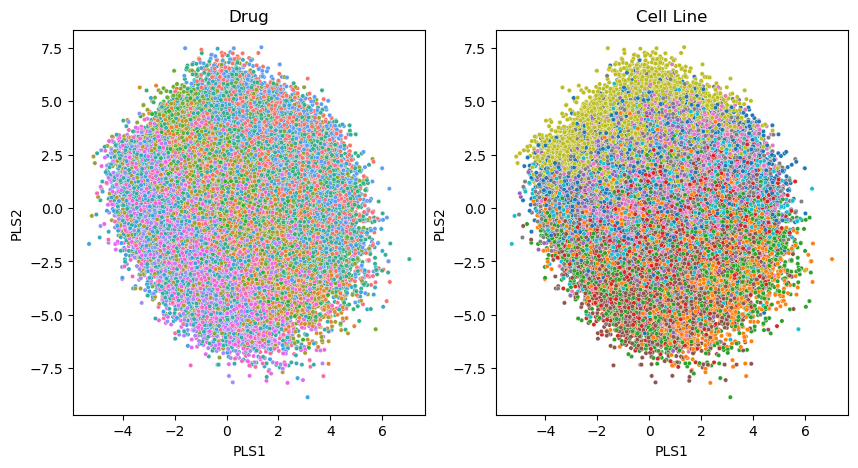

In [26]:
# subset to 20% of the dataset
# n_per_condition = int(np.round(proj_df.drug.value_counts().min() * 0.2))

# # Subsample indices evenly per condition
# sampled_indices = (
#     proj_df.groupby('drug')
#     .sample(n=n_per_condition, random_state=seed)
#     .index
# )

n_per_condition = int(np.round(tf_adata.obs['condition'].value_counts().min() * 0.2))

# Subsample indices evenly per condition
sampled_indices = (
    proj_df.groupby('condition')
    .sample(n=n_per_condition, random_state=seed)
    .index
)

# shuffle
np.random.seed(seed)
sampled_indices=np.random.permutation(sampled_indices)

viz_df = proj_df.loc[sampled_indices, :].copy()

fig, ax = plt.subplots(ncols = 2, figsize = (10, 5))


# DRUG
sns.scatterplot(data = viz_df, x = 'PLS1', y = 'PLS2', hue = 'drug', 
               s = 10, ax = ax[0])
ax[0].legend_.remove()
ax[0].set_title('Drug')

# Cell Line
sns.scatterplot(data = viz_df, x = 'PLS1', y = 'PLS2', hue = 'cell_line', 
               s = 10, ax = ax[1])
ax[1].legend_.remove()
ax[1].set_title('Cell Line')

;

Next, also fit the UMAP with the PLS and drug covariates:

Step 2: Fit a guided UMAP on the PLS components

In [27]:
%%time
umap_model = umap.UMAP(n_neighbors=15, 
                    n_components=2,
                    metric='euclidean', 
                    target_metric='categorical', 
                    random_state = seed)
umap_model.fit(X_pls,
               tf_adata.obs['drug'].cat.codes.values)
embedding = umap_model.transform(X_pls)

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


CPU times: user 47min 31s, sys: 6min 34s, total: 54min 6s
Wall time: 11min 55s


''

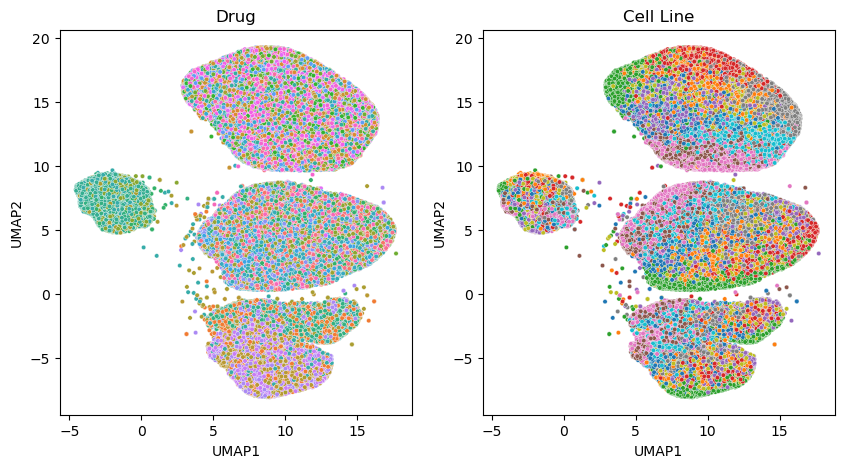

In [28]:
viz_df = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'])
viz_df['drug'] = tf_adata.obs.drug.astype(str).values
viz_df['cell_line'] = tf_adata.obs.cell_line.astype(str).values
viz_df = viz_df.loc[sampled_indices, :]

fig, ax = plt.subplots(ncols = 2, figsize = (10, 5))


# DRUG
sns.scatterplot(data = viz_df, x = 'UMAP1', y = 'UMAP2', hue = 'drug', 
               s = 10, ax = ax[0])
ax[0].legend_.remove()
ax[0].set_title('Drug')

# Cell Line
sns.scatterplot(data = viz_df, x = 'UMAP1', y = 'UMAP2', hue = 'cell_line', 
               s = 10, ax = ax[1])
ax[1].legend_.remove()
ax[1].set_title('Cell Line')

;

In [29]:
for model_type, model in models.items():
    if model is not None:
        joblib.dump(model, os.path.join(data_path, 'processed', author + '_drug_' + model_type + '.joblib'))
joblib.dump(umap_model, os.path.join(data_path, 'processed', author + '_drug_umap.joblib'))

['/nobackup/users/hmbaghda/scLEMBAS/analysis/processed/Tahoe100M_drug_umap.joblib']

# Use downstream

get the pipeline to project newly predicted values into this embedding

Load the trained models:

In [ ]:
# import joblib

# pls_model = joblib.load(os.path.join(data_path, 'processed', author + '_drug_pls_model.joblib'))
# enc_X = joblib.load(os.path.join(data_path, 'processed', author + '_drug_encoder_x.joblib'))
# enc_Y = joblib.load(os.path.join(data_path, 'processed', author + '_drug_encoder_y.joblib'))
# umap_model = joblib.load(os.path.join(data_path, 'processed', author + '_drug_umap.joblib'))

# X_pred, _ = prepare_input_matrix(tf_adata = tf_adata_predicted, 
#                            control_confounders = True, 
#                            enc_X = enc_X)
# X_pls_pred = pls_model.transform(X_pred)
# embedding_predicted = umap_model.transform(X_pls_pred)